In [70]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize
from matplotlib.pyplot import figure
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

In [71]:
X,y = make_regression(
    n_samples=100
    , n_features=1
    , noise=20
    , random_state=42
)

In [72]:
df = pd.DataFrame({
    "feature": X.flatten(),
    "target": y
})

In [73]:
df

,feature,target
0,0.931280,62.687202
1,0.087047,-23.763981
2,-1.057711,-25.686766
3,0.314247,7.936457
4,-0.479174,-15.475495
...,...,...
95,1.852278,78.854028
96,-1.424748,-82.466409
97,-0.719844,-47.757337
98,-0.072010,11.684240


In [74]:
df.describe()

,feature,target
count,100.000000,100.000000
mean,-0.103847,-2.564392
std,0.908168,46.342550
min,-2.619745,-126.703865
25%,-0.600906,-33.801999
50%,-0.126956,0.354463
75%,0.405952,25.794133
max,1.852278,116.377367


In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   feature  100 non-null    float64
 1   target   100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


In [76]:
X_train, X_test, y_train, y_test= train_test_split(df[["feature"]], df["target"] , test_size=0.2, random_state=42)

In [77]:
linear_regressor  = LinearRegression()

In [78]:
linear_regressor.fit(X = X_train, y = y_train , sample_weight=None)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [79]:
w = linear_regressor.coef_
b = linear_regressor.intercept_

In [80]:
def predict(x):
    return linear_regressor.predict(x)

In [82]:
y_pred = linear_regressor.predict(X_test)
y_pred

array([-61.89061944,  69.2859475 ,  38.18180355, -18.13153892,
       -10.7475852 , -13.4374403 , -21.57314731, -82.21885915,
        38.62013778,  43.73324201,  48.39485129,  16.89248009,
       -56.87265598, -24.56639567, -53.60735619, -22.20164017,
        45.80251003,  11.50951861,  34.7197366 ,  17.76129888])

In [85]:
from sklearn.metrics import mean_squared_error , root_mean_squared_error,mean_absolute_error, r2_score

In [86]:
mse = mean_squared_error(y_test , y_pred)
mae = mean_absolute_error(y_test , y_pred)
rmse = root_mean_squared_error(y_test , y_pred)
r2_score = r2_score(y_test , y_pred)

In [87]:
print("MSE:",mse)
print("MAE:",mae)
print("RMSE:",rmse)
print("R2:",r2_score)

MSE: 416.80890612748107
MAE: 16.833319844418106
RMSE: 20.41589836689733
R2: 0.8019015156159199


In [88]:
df["target"].describe()

count    100.000000
mean      -2.564392
std       46.342550
min     -126.703865
25%      -33.801999
50%        0.354463
75%       25.794133
max      116.377367
Name: target, dtype: float64

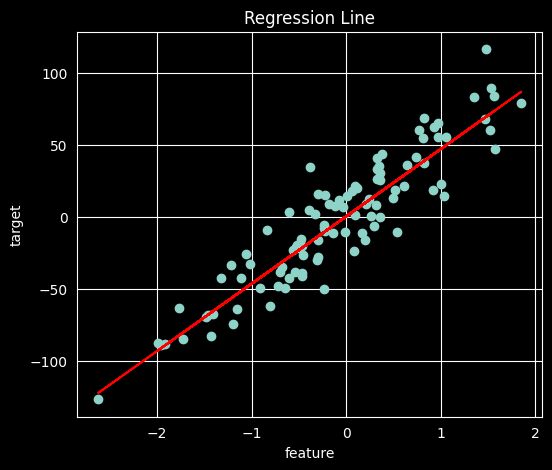

In [127]:
plt.figure(figsize=(6,5))
plt.scatter(X, y)
X_sorted = np.sort(X)
y_line = linear_regressor.predict(X_sorted)
plt.plot(X_sorted, y_line, 'r')
plt.xlabel("feature")
plt.ylabel("target")
plt.title("Regression Line")
plt.show()

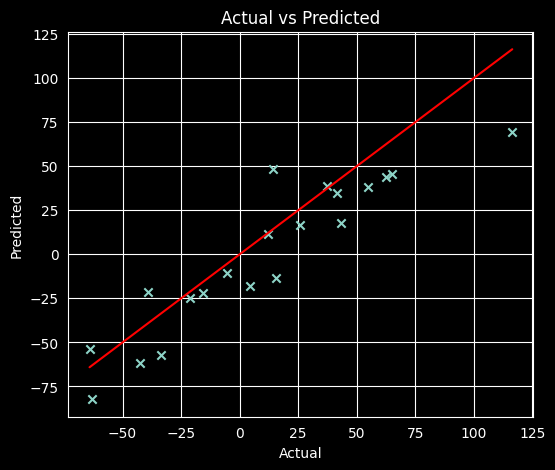

In [126]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, marker="x")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()